# Assignment 3: ML-Driven Portfolio Optimization

Aim - To train an **XGBoost classifier** that predicts cross-sectional outperformance on NIFTY-50 stocks, **screen** the universe at $\hat p_i > 0.51$, then run **long-only Markowitz** on the survivors. Compare against equal-weight and plain Markowitz baselines on both the **Full** (49 stocks, 2010–2021) and **Extended** (37 stocks, 2004–2021) universes. Feature selection is done via a two-stage walk-forward search (group ablation → RM subset).

Also refer to [README](README.md).


## Setup

In [1]:
from pathlib import Path
import warnings
from itertools import combinations

import cvxpy as cp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import spearmanr
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from IPython.display import display

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

## Data and Two Universes

Two processed price matrices from `data/Data_Pipeline.ipynb`:

- **Full** — `data/processed/price_matrix_full.csv`, 49 NIFTY-50 constituents with the common window where every stock has data: **2010-11-04 → 2021-04-30** (2,598 trading days).
- **Extended** — `data/processed/price_matrix_extended.csv`, 37 constituents that traded across the longer window: **2004-01-23 → 2021-04-30** (4,286 trading days).

Trade-off: breadth (Full) vs depth (Extended). The pseudo column `NIFTY50_all` is dropped from each matrix before modelling.

In [2]:
DATA_DIR = next(
    (base / "data" / "processed"
     for base in [Path.cwd(), *Path.cwd().parents]
     if (base / "data" / "processed" / "price_matrix_full.csv").exists()),
    None,
)
if DATA_DIR is None:
    raise FileNotFoundError("data/processed/price_matrix_full.csv")

In [3]:
def load_price_matrix(filename):
    df = pd.read_csv(DATA_DIR / filename, parse_dates=["Date"]).set_index("Date").sort_index()
    if "NIFTY50_all" in df.columns:
        df = df.drop(columns="NIFTY50_all")
    return df

In [4]:
price_matrix_full     = load_price_matrix("price_matrix_full.csv")
price_matrix_extended = load_price_matrix("price_matrix_extended.csv")

universe_summary = pd.DataFrame([
    {"Universe": lbl, "Stocks": p.shape[1], "Trading Days": p.shape[0],
     "Start": p.index.min().date(), "End": p.index.max().date()}
    for lbl, p in [("Full", price_matrix_full), ("Extended", price_matrix_extended)]
])
display(universe_summary)

,Universe,Stocks,Trading Days,Start,End
0,Full,49,2598,2010-11-04,2021-04-30
1,Extended,37,4286,2004-01-23,2021-04-30


## Train / Test Split

Train: everything up to **2018-12-31**. Test: **2019-01-01 → 2021-04-30** (~2.5 years, includes COVID).

In [5]:
TRAIN_END = pd.Timestamp("2018-12-31")


def split_returns(price_mat):
    rets  = price_mat.pct_change().dropna()
    train = rets.loc[:TRAIN_END]
    test  = rets.loc[TRAIN_END + pd.Timedelta(days=1):]
    return rets, train, test

In [6]:
returns_full, train_full, test_full = split_returns(price_matrix_full)
returns_ext,  train_ext,  test_ext  = split_returns(price_matrix_extended)

split_summary = pd.DataFrame([
    {"Universe": lbl, "Train days": len(tr), "Test days": len(te),
     "Train start": tr.index.min().date(), "Train end": tr.index.max().date(),
     "Test start":  te.index.min().date(), "Test end":  te.index.max().date()}
    for lbl, tr, te in [("Full", train_full, test_full), ("Extended", train_ext, test_ext)]
])
display(split_summary)

,Universe,Train days,Test days,Train start,Train end,Test start,Test end
0,Full,2020,577,2010-11-05,2018-12-31,2019-01-01,2021-04-30
1,Extended,3708,577,2004-01-27,2018-12-31,2019-01-01,2021-04-30


## Features

**Target.** Forward 21-day return (≈ 1 month), cross-sectionally demeaned so the classifier learns *selection*, not *market direction*:

$$R_{i,t} = \frac{P_{i,t+21}}{P_{i,t}} - 1, \qquad y_{i,t} = \mathbf 1\bigl[R_{i,t} - \bar R_t > 0\bigr].$$

**Feature pool (20 features per stock-date).** Three groups:

- **Daily lags:** $r_{t-k}$, $k \in \{1, \ldots, 5\}$ — 5 features.
- **Monthly lags:** $r_{t-k}$, $k \in \{21, 42, \ldots, 252\}$ — 12 features.
- **Rolling means:** of daily returns over $\{63, 126, 252\}$-day windows — 3 features.

All rolling means use `shift(1)` before the rolling window so the feature at time $t$ uses data strictly before $t$.

In [7]:
H = 21  # forecast horizon (≈ 1 month)

DAILY_LAGS   = [1, 2, 3, 4, 5]
MONTHLY_LAGS = [21, 42, 63, 84, 105, 126, 147, 168, 189, 210, 231, 252]
RM_WINDOWS   = [63, 126, 252]

FEATURES = (
    [f"ret_lag_{k}" for k in DAILY_LAGS + MONTHLY_LAGS]
    + [f"rm_{w}" for w in RM_WINDOWS]
)

In [8]:
def build_panel(prices, returns, horizon=H):
    # per-stock (date, features, forward-return) panel for classifier training
    rows = []
    for sym in prices.columns:
        p, r = prices[sym], returns[sym]
        df = pd.DataFrame(index=p.index)
        for k in DAILY_LAGS + MONTHLY_LAGS:
            df[f"ret_lag_{k}"] = r.shift(k)
        for w in RM_WINDOWS:
            df[f"rm_{w}"] = r.shift(1).rolling(w).mean()  # shift(1) avoids look-ahead
        df["y"]           = p.shift(-horizon) / p - 1
        df["target_date"] = df.index.to_series().shift(-horizon)
        df["symbol"]      = sym
        rows.append(df)
    return pd.concat(rows).dropna()

In [9]:
panel_full = build_panel(price_matrix_full,     returns_full)
panel_ext  = build_panel(price_matrix_extended, returns_ext)

print(f"Forecast horizon    : H = {H} trading days (~1 month)")
print(f"Number of features  : {len(FEATURES)}")
print(f"Full panel rows     : {len(panel_full):,}")
print(f"Extended panel rows : {len(panel_ext):,}")

Forecast horizon    : H = 21 trading days (~1 month)
Number of features  : 20
Full panel rows     : 113,876
Extended panel rows : 148,444


## Classifier

XGBoost binary classifier on the 20-feature panel, target = cross-sectionally demeaned forward return sign. Sample-weight time decay:

$$w_i = 0.5^{(T_{\text{end}} - t_i) / (365.25 \cdot 2)}$$

2-year half-life on training samples matches the 2-year EWMA half-life used for $\mu, \Sigma$ in the portfolio step — both decay-rates aligned so the recent regime dominates both stages.

In [10]:
HALF_LIFE_YEARS  = 2.0
P_BUY_THRESHOLD  = 0.51  # ML class screen cutoff


def cross_sectional_demean(panel, col="y"):
    # remove daily market trend so classifier sees relative outperformance
    return panel[col] - panel.groupby(panel.index)[col].transform("mean")


def _half_life_weights(train_index, train_end):
    age_days = (train_end - train_index).days.values.astype(float)
    return 0.5 ** (age_days / (365.25 * HALF_LIFE_YEARS))


def _xgb(n_est):
    return XGBClassifier(
        n_estimators=n_est, max_depth=4, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0,
        random_state=0, n_jobs=-1, verbosity=0, eval_metric="logloss",
    )

The fit helper splits the panel on `train_end`, demeans the target, standardises features, applies sample-weight decay, and optionally warm-starts from a previously trained booster (used by the walk-forward CV below).

In [11]:
def fit_classifier(panel, train_end=TRAIN_END, features=None, warm_booster=None):
    features = features or FEATURES
    train = panel.loc[panel["target_date"] <= train_end].copy()
    test  = panel.loc[panel.index > train_end].copy()

    train["y_class"] = (cross_sectional_demean(train, "y") > 0).astype(int)

    scaler = StandardScaler().fit(train[features])
    Xtr = scaler.transform(train[features])
    Xte = scaler.transform(test[features])

    sample_w = _half_life_weights(train.index, train_end)
    n_est    = 300 if warm_booster is None else 100  # warm-start appends fewer trees
    clf = _xgb(n_est)
    fit_kwargs = {"sample_weight": sample_w}
    if warm_booster is not None:
        fit_kwargs["xgb_model"] = warm_booster
    clf.fit(Xtr, train["y_class"].values, **fit_kwargs)

    return clf, scaler, train, test, clf.predict_proba(Xte)[:, 1]

## Walk-Forward Feature Selection

Six expanding (train, val) folds with validation years **2013–2018**. Score = mean val Sharpe of the **ML class + Markowitz** portfolio at $\gamma = 0.05$. Warm-start: each fold inherits the prior booster plus 100 new trees.

Search factorised into two stages:

- **Stage A**: leave-one-out group ablation. Drop a feature group iff val Sharpe improves by at least $\Delta \ge 0.05$.
- **Stage B**: exhaustive search over non-empty subsets of surviving RM windows. At most 11 candidates.

In [12]:
VAL_YEARS    = [2013, 2014, 2015, 2016, 2017, 2018]
CV_GAMMA     = 0.05
CV_THRESHOLD = P_BUY_THRESHOLD
ABLATION_EPS = 0.05


def feature_groups():
    return {
        "daily_lags":    [f"ret_lag_{k}" for k in DAILY_LAGS],
        "monthly_lags":  [f"ret_lag_{k}" for k in MONTHLY_LAGS],
        "rolling_means": [f"rm_{w}" for w in RM_WINDOWS],
    }

In [13]:
def make_folds(panel, val_years=VAL_YEARS):
    folds = []
    for Y in val_years:
        end   = pd.Timestamp(f"{Y - 1}-12-31")
        start = pd.Timestamp(f"{Y}-01-01")
        stop  = pd.Timestamp(f"{Y}-12-31")
        tr_idx = panel.index[panel["target_date"] <= end]
        va_idx = panel.index[(panel.index >= start) & (panel["target_date"] <= stop)]
        if len(tr_idx) < 100 or len(va_idx) < 10:
            continue
        folds.append({"val_year": Y, "train_end": end, "val_start": start,
                       "val_end": stop, "train_idx": tr_idx, "val_idx": va_idx})
    return folds

In [14]:
folds_full = make_folds(panel_full)
folds_ext  = make_folds(panel_ext)

display(pd.DataFrame([
    {"Universe": lbl, "Val year": f["val_year"],
     "Train end": f["train_end"].date(), "Val start": f["val_start"].date(),
     "Train rows": len(f["train_idx"]), "Val rows": len(f["val_idx"])}
    for lbl, fl in [("Full", folds_full), ("Extended", folds_ext)] for f in fl
]))

,Universe,Val year,Train end,Val start,Train rows,Val rows
0,Full,2013,2012-12-31,2013-01-01,12936,11221
1,Full,2014,2013-12-31,2014-01-01,25186,10927
2,Full,2015,2014-12-31,2015-01-01,37142,11123
3,Full,2016,2015-12-31,2016-01-01,49294,11074
4,Full,2017,2016-12-31,2017-01-01,61397,11123
5,Full,2018,2017-12-31,2018-01-01,73549,11025
6,Extended,2013,2012-12-31,2013-01-01,72224,8473
7,Extended,2014,2013-12-31,2014-01-01,81474,8251
8,Extended,2015,2014-12-31,2015-01-01,90502,8399
9,Extended,2016,2015-12-31,2016-01-01,99678,8362


### Portfolio helpers used by the fold scorer

**EWMA $\mu, \Sigma$** with 504-day (2 trading years) half-life — same decay as the classifier sample-weight.

$$\mu_i = 252 \sum_t w_t r_{i,t}, \qquad \Sigma_{ij} = 252 \sum_t w_t (r_{i,t} - \mu_i / 252)(r_{j,t} - \mu_j / 252).$$

In [15]:
EWMA_HALF_LIFE_DAYS = 504  # 2 trading years, matches classifier decay


def ewma_weights(n, half_life=EWMA_HALF_LIFE_DAYS):
    ages = np.arange(n - 1, -1, -1, dtype=float)
    w = 0.5 ** (ages / half_life)
    return w / w.sum()

In [16]:
def ewma_mu(rets, half_life=EWMA_HALF_LIFE_DAYS):
    X = rets.dropna()
    w = ewma_weights(len(X), half_life)
    return pd.Series((X.values * w[:, None]).sum(axis=0) * 252, index=X.columns)


def ewma_cov(rets, half_life=EWMA_HALF_LIFE_DAYS):
    X  = rets.dropna()
    w  = ewma_weights(len(X), half_life)
    mu = (X.values * w[:, None]).sum(axis=0)
    Xc = X.values - mu
    cov = (Xc * w[:, None]).T @ Xc  # weighted outer product
    return pd.DataFrame(cov * 252, index=X.columns, columns=X.columns)

**Portfolio evaluator** — Sharpe, annualised return, vol, max drawdown, CAGR, effective N.

In [17]:
def evaluate_portfolio(weights, test_returns):
    syms = weights.index.intersection(test_returns.columns)
    w    = weights.loc[syms].values
    r    = test_returns[syms].values
    daily = r @ w

    ann_ret = float(daily.mean() * 252)
    ann_vol = float(daily.std(ddof=1) * np.sqrt(252))
    sharpe  = ann_ret / ann_vol if ann_vol > 0 else np.nan

    cum   = (1 + daily).cumprod()
    dd    = (cum - np.maximum.accumulate(cum)) / np.maximum.accumulate(cum)
    years = len(test_returns) / 252
    cagr  = float(cum[-1] ** (1 / years) - 1) if years > 0 else np.nan

    return {"Sharpe": sharpe, "Ann. Return": ann_ret, "Ann. Vol": ann_vol,
            "Max DD": float(dd.min()), "CAGR": cagr,
            "N_eff": float(1.0 / (w ** 2).sum())}, daily

**MVO** — long-only fully-invested, SCS solver. Falls back to equal weight if the solver fails.

$$\min_w \; \tfrac12 w^\top \Sigma w - \gamma \mu^\top w \quad \text{s.t.} \quad \mathbf 1^\top w = 1, \;\; w \ge 0.$$

In [18]:
def mvo_solve(mu, sigma, gamma):
    n = len(mu)
    w = cp.Variable(n)
    prob = cp.Problem(
        cp.Minimize(0.5 * cp.quad_form(w, sigma.values) - gamma * (mu.values @ w)),
        [cp.sum(w) == 1, w >= 0],
    )
    prob.solve(solver=cp.SCS, verbose=False, eps=1e-5, max_iters=20000)
    if w.value is None:
        return pd.Series(1.0 / n, index=mu.index)
    wt = np.clip(np.array(w.value).ravel(), 0, None)  # clip solver noise
    return pd.Series(wt / wt.sum(), index=mu.index)

### Per-fold scorer

Three helpers compose the walk-forward score:

In [19]:
def _fit_fold_clf(panel, fold, features, warm_booster=None):
    tr = panel.loc[fold["train_idx"]].copy()
    va = panel.loc[fold["val_idx"]].copy()
    tr["y_class"] = (cross_sectional_demean(tr, "y") > 0).astype(int)

    scaler = StandardScaler().fit(tr[features])
    Xtr = scaler.transform(tr[features])
    Xva = scaler.transform(va[features])

    sample_w = _half_life_weights(tr.index, fold["train_end"])
    n_est    = 300 if warm_booster is None else 100
    clf = _xgb(n_est)
    fit_kwargs = {"sample_weight": sample_w}
    if warm_booster is not None:
        fit_kwargs["xgb_model"] = warm_booster
    clf.fit(Xtr, tr["y_class"].values, **fit_kwargs)

    return clf, clf.predict_proba(Xva)[:, 1], va

In [20]:
def _eval_fold_portfolio(val_sl, proba_val, all_returns, fold,
                         gamma=CV_GAMMA, threshold=CV_THRESHOLD):
    # average predicted P per stock over val window, keep those above threshold
    p_val = (pd.DataFrame({"symbol": val_sl["symbol"].values, "p": proba_val},
                          index=val_sl.index)
               .groupby("symbol")["p"].mean())
    keep = p_val[p_val > threshold].index
    if len(keep) < 2:
        return np.nan

    train_rets = all_returns.loc[:fold["train_end"]]
    avail = keep.intersection(train_rets.columns)
    if len(avail) < 2:
        return np.nan

    mu  = ewma_mu(train_rets[avail])
    Sig = ewma_cov(train_rets[avail])
    w   = mvo_solve(mu, Sig, gamma)
    val_rets = all_returns.loc[fold["val_start"]:fold["val_end"]]
    return evaluate_portfolio(w, val_rets)[0]["Sharpe"]

In [21]:
def walk_forward_score(panel, all_returns, features, folds):
    # chain folds with warm-start booster reuse; return mean Sharpe
    sharpes, last_booster = [], None
    for fold in folds:
        clf, proba_val, val_sl = _fit_fold_clf(panel, fold, features, last_booster)
        last_booster = clf.get_booster()
        sharpes.append(_eval_fold_portfolio(val_sl, proba_val, all_returns, fold))
    valid = [s for s in sharpes if not np.isnan(s)]
    return float(np.mean(valid)) if valid else np.nan, sharpes, last_booster

### Stage A — group ablation

Leave-one-out across the three feature groups. Drop a group iff the val Sharpe rises by $\ge 0.05$ when removed.

In [22]:
def ablate_groups(panel, all_returns, folds, eps=ABLATION_EPS):
    groups    = feature_groups()
    all_feats = sum(groups.values(), [])
    base, _, _ = walk_forward_score(panel, all_returns, all_feats, folds)
    rows = [{"Config": "Baseline (all groups)", "Features": len(all_feats),
             "Mean val Sharpe": base, "Delta vs baseline": 0.0}]
    for name, feats in groups.items():
        kept = [f for f in all_feats if f not in feats]
        s, _, _ = walk_forward_score(panel, all_returns, kept, folds)
        print(f"Drop {name:14s}: Sharpe {s:.4f} (delta {s - base:+.4f})")
        rows.append({"Config": f"Drop {name}", "Features": len(kept),
                     "Mean val Sharpe": s, "Delta vs baseline": s - base})
    return pd.DataFrame(rows), base

In [23]:
abl_full, base_full = ablate_groups(panel_full, returns_full, folds_full)
abl_ext,  base_ext  = ablate_groups(panel_ext,  returns_ext,  folds_ext)

print("Full universe:")
display(abl_full.style.format({"Mean val Sharpe": "{:.4f}", "Delta vs baseline": "{:+.4f}"}))
print("\nExtended universe:")
display(abl_ext.style.format({"Mean val Sharpe": "{:.4f}", "Delta vs baseline": "{:+.4f}"}))

Drop daily_lags    : Sharpe 1.2411 (delta +0.0011)
Drop monthly_lags  : Sharpe 0.9581 (delta -0.2819)
Drop rolling_means : Sharpe 0.4653 (delta -0.7747)
Drop daily_lags    : Sharpe 1.1802 (delta -0.0099)
Drop monthly_lags  : Sharpe 1.6351 (delta +0.4450)
Drop rolling_means : Sharpe 0.6292 (delta -0.5609)
Full universe:


,Config,Features,Mean val Sharpe,Delta vs baseline
0,Baseline (all groups),20,1.2400,+0.0000
1,Drop daily_lags,15,1.2411,+0.0011
2,Drop monthly_lags,8,0.9581,-0.2819
3,Drop rolling_means,17,0.4653,-0.7747



Extended universe:


,Config,Features,Mean val Sharpe,Delta vs baseline
0,Baseline (all groups),20,1.1901,+0.0000
1,Drop daily_lags,15,1.1802,-0.0099
2,Drop monthly_lags,8,1.6351,+0.4450
3,Drop rolling_means,17,0.6292,-0.5609


In [24]:
def _stage_a_read(lbl, abl):
    drops = abl[abl["Config"].str.startswith("Drop")]
    msg   = f"Stage A - {lbl}: "
    triggered = drops[drops["Delta vs baseline"] >= ABLATION_EPS]
    if triggered.empty:
        msg += f"no group drops (max Δ = {drops['Delta vs baseline'].max():+.4f} < {ABLATION_EPS})."
    else:
        for _, r in triggered.iterrows():
            grp = r["Config"].replace("Drop ", "")
            msg += f"drop {grp} (Δ = {r['Delta vs baseline']:+.4f}). "
    print(msg)


_stage_a_read("Full",     abl_full)
_stage_a_read("Extended", abl_ext)

Stage A - Full: no group drops (max Δ = +0.0011 < 0.05).
Stage A - Extended: drop monthly_lags (Δ = +0.4450). 


In [25]:
def surviving_non_rm(abl_df):
    g = feature_groups()
    kept = g["daily_lags"] + g["monthly_lags"]
    for grp in ["daily_lags", "monthly_lags"]:
        row = abl_df[abl_df["Config"] == f"Drop {grp}"]
        if not row.empty and float(row["Delta vs baseline"].values[0]) >= ABLATION_EPS:
            kept = [f for f in kept if f not in g[grp]]
    return kept


def rm_dropped(abl_df):
    row = abl_df[abl_df["Config"] == "Drop rolling_means"]
    return float(row["Delta vs baseline"].values[0]) >= ABLATION_EPS


kept_non_rm_full = surviving_non_rm(abl_full)
kept_non_rm_ext  = surviving_non_rm(abl_ext)
rm_dropped_full  = rm_dropped(abl_full)
rm_dropped_ext   = rm_dropped(abl_ext)

### Stage B — RM subset search

Exhaustive search over non-empty subsets of surviving RM windows. Skipped if Stage A dropped the RM group entirely.

In [26]:
def search_rm_windows(panel, all_returns, folds, base_non_rm):
    rows, best_s, best = [], -np.inf, None
    for r in range(1, len(RM_WINDOWS) + 1):
        for subset in combinations(RM_WINDOWS, r):
            feats = base_non_rm + [f"rm_{w}" for w in subset]
            s, _, _ = walk_forward_score(panel, all_returns, feats, folds)
            print(f"RM subset: {subset}, Features: {len(feats)}, Mean val Sharpe: {s:.4f}")
            rows.append({"RM subset": str(list(subset)),
                         "Features": len(feats), "Mean val Sharpe": s})
            if not np.isnan(s) and s > best_s:
                best_s, best = s, list(subset)
    return best, pd.DataFrame(rows).sort_values("Mean val Sharpe", ascending=False)

In [27]:
best_rm_full, rm_table_full = ([], pd.DataFrame()) if rm_dropped_full else \
    search_rm_windows(panel_full, returns_full, folds_full, kept_non_rm_full)
best_rm_ext,  rm_table_ext  = ([], pd.DataFrame()) if rm_dropped_ext  else \
    search_rm_windows(panel_ext,  returns_ext,  folds_ext,  kept_non_rm_ext)

if not rm_dropped_full:
    print("Full:");     display(rm_table_full.style.format({"Mean val Sharpe": "{:.4f}"}))
if not rm_dropped_ext:
    print("Extended:"); display(rm_table_ext.style.format({"Mean val Sharpe": "{:.4f}"}))

RM subset: (63,), Features: 18, Mean val Sharpe: 0.9557
RM subset: (126,), Features: 18, Mean val Sharpe: 0.9005
RM subset: (252,), Features: 18, Mean val Sharpe: 1.1180
RM subset: (63, 126), Features: 19, Mean val Sharpe: 0.9591
RM subset: (63, 252), Features: 19, Mean val Sharpe: 0.9449
RM subset: (126, 252), Features: 19, Mean val Sharpe: 0.9797
RM subset: (63, 126, 252), Features: 20, Mean val Sharpe: 1.2400
RM subset: (63,), Features: 6, Mean val Sharpe: 1.6330
RM subset: (126,), Features: 6, Mean val Sharpe: 1.5491
RM subset: (252,), Features: 6, Mean val Sharpe: 1.8236
RM subset: (63, 126), Features: 7, Mean val Sharpe: 1.6017
RM subset: (63, 252), Features: 7, Mean val Sharpe: 1.3845
RM subset: (126, 252), Features: 7, Mean val Sharpe: 1.3457
RM subset: (63, 126, 252), Features: 8, Mean val Sharpe: 1.6351
Full:


,RM subset,Features,Mean val Sharpe
6,"[63, 126, 252]",20,1.2400
2,[252],18,1.1180
5,"[126, 252]",19,0.9797
3,"[63, 126]",19,0.9591
0,[63],18,0.9557
4,"[63, 252]",19,0.9449
1,[126],18,0.9005


Extended:


,RM subset,Features,Mean val Sharpe
2,[252],6,1.8236
6,"[63, 126, 252]",8,1.6351
0,[63],6,1.6330
3,"[63, 126]",7,1.6017
1,[126],6,1.5491
4,"[63, 252]",7,1.3845
5,"[126, 252]",7,1.3457


In [28]:
def _stage_b_read(lbl, rm_dropped_flag, rm_table, best_rm):
    if rm_dropped_flag:
        print(f"Stage B - {lbl}: RM group dropped by Stage A, no subset search.")
        return
    if rm_table.empty:
        print(f"Stage B - {lbl}: empty table.")
        return
    top = rm_table.iloc[0]
    print(f"Stage B - {lbl}: best subset = {best_rm} (val Sharpe {top['Mean val Sharpe']:.4f}).")


_stage_b_read("Full",     rm_dropped_full, rm_table_full, best_rm_full)
_stage_b_read("Extended", rm_dropped_ext,  rm_table_ext,  best_rm_ext)

Stage B - Full: best subset = [63, 126, 252] (val Sharpe 1.2400).
Stage B - Extended: best subset = [252] (val Sharpe 1.8236).


In [29]:
def build_final_features(kept_non_rm, best_rm_windows):
    return kept_non_rm + [f"rm_{w}" for w in best_rm_windows]


FINAL_FEATURES_FULL = build_final_features(kept_non_rm_full, best_rm_full)
FINAL_FEATURES_EXT  = build_final_features(kept_non_rm_ext,  best_rm_ext)

_, fold_sharpes_full, _ = walk_forward_score(panel_full, returns_full, FINAL_FEATURES_FULL, folds_full)
_, fold_sharpes_ext,  _ = walk_forward_score(panel_ext,  returns_ext,  FINAL_FEATURES_EXT,  folds_ext)

print(f"FINAL_FEATURES_FULL ({len(FINAL_FEATURES_FULL)} features):")
print("  ", FINAL_FEATURES_FULL)
print()
print(f"FINAL_FEATURES_EXT ({len(FINAL_FEATURES_EXT)} features):")
print("  ", FINAL_FEATURES_EXT)

FINAL_FEATURES_FULL (20 features):
   ['ret_lag_1', 'ret_lag_2', 'ret_lag_3', 'ret_lag_4', 'ret_lag_5', 'ret_lag_21', 'ret_lag_42', 'ret_lag_63', 'ret_lag_84', 'ret_lag_105', 'ret_lag_126', 'ret_lag_147', 'ret_lag_168', 'ret_lag_189', 'ret_lag_210', 'ret_lag_231', 'ret_lag_252', 'rm_63', 'rm_126', 'rm_252']

FINAL_FEATURES_EXT (6 features):
   ['ret_lag_1', 'ret_lag_2', 'ret_lag_3', 'ret_lag_4', 'ret_lag_5', 'rm_252']


In [30]:
fold_df = pd.DataFrame({
    "Val year":        VAL_YEARS,
    "Full Sharpe":     fold_sharpes_full,
    "Extended Sharpe": fold_sharpes_ext,
})
display(fold_df.style.format({"Full Sharpe": "{:.3f}", "Extended Sharpe": "{:.3f}"}, na_rep="-"))
print(f"Full mean: {pd.Series(fold_sharpes_full).mean():.3f} | "
      f"Extended mean: {pd.Series(fold_sharpes_ext).mean():.3f}")

,Val year,Full Sharpe,Extended Sharpe
0,2013,0.040,-0.271
1,2014,2.730,5.376
2,2015,0.607,1.438
3,2016,-,0.371
4,2017,2.959,3.923
5,2018,-0.136,0.106


Full mean: 1.240 | Extended mean: 1.824


## Final Classifier Fit

Fit the final XGBoost classifier on the full pre-2019 train window using the features Stage A + B selected per universe.

In [31]:
clf_full, scaler_full, tr_f, te_f, proba_f = fit_classifier(
    panel_full, features=FINAL_FEATURES_FULL,
)
clf_ext, scaler_ext, tr_e, te_e, proba_e = fit_classifier(
    panel_ext, features=FINAL_FEATURES_EXT,
)

print(f"Full     - train rows: {len(tr_f):,} | test rows: {len(te_f):,} | features: {len(FINAL_FEATURES_FULL)}")
print(f"Extended - train rows: {len(tr_e):,} | test rows: {len(te_e):,} | features: {len(FINAL_FEATURES_EXT)}")

Full     - train rows: 85,603 | test rows: 27,244 | features: 20
Extended - train rows: 127,095 | test rows: 20,572 | features: 6


Feature importance (gain) per universe — which signals actually drive the predictions.

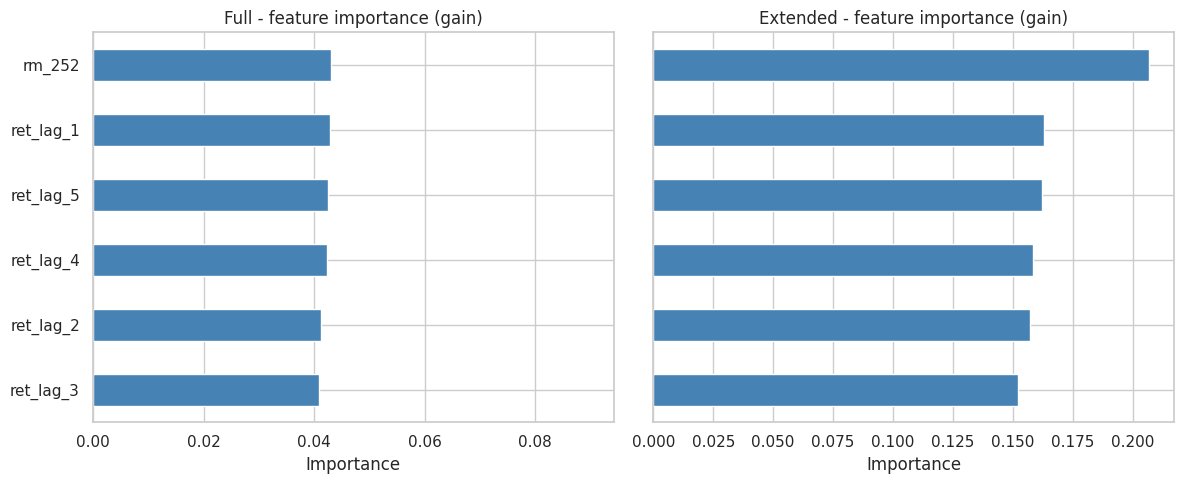

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
for ax, lbl, clf, feats in [
    (axes[0], "Full",     clf_full, FINAL_FEATURES_FULL),
    (axes[1], "Extended", clf_ext,  FINAL_FEATURES_EXT),
]:
    imp = pd.Series(clf.feature_importances_, index=feats).sort_values()
    imp.plot.barh(ax=ax, color="steelblue")
    ax.set_title(f"{lbl} - feature importance (gain)")
    ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

In [33]:
for lbl, clf, feats in [("Full", clf_full, FINAL_FEATURES_FULL),
                        ("Extended", clf_ext, FINAL_FEATURES_EXT)]:
    imp  = pd.Series(clf.feature_importances_, index=feats).sort_values(ascending=False)
    top3 = ", ".join(f"{f} ({v:.1%})" for f, v in imp.head(3).items())
    print(f"{lbl}: top 3 = {top3}")

Full: top 3 = rm_126 (9.0%), rm_252 (8.3%), rm_63 (7.9%)
Extended: top 3 = rm_252 (20.7%), ret_lag_1 (16.3%), ret_lag_5 (16.2%)


## Classifier Metrics

Buy accuracy: $P > 0.5$ matches realised $y > 0$. Buy / sell mean return: average raw 21-day return on each side. Spearman rank IC: $\mathrm{IC}_t = \rho(P_{\cdot, t}, R_{\cdot, t})$; IR = mean / std.

In [34]:
def classifier_metrics(proba, y):
    pred = (proba > 0.5).astype(int)
    real = (y > 0).astype(int)
    return {
        "Buy accuracy":      float((pred == real).mean()),
        "Buy-set mean ret":  float(y[proba > 0.5].mean())  if (proba > 0.5).any()  else np.nan,
        "Sell-set mean ret": float(y[proba <= 0.5].mean()) if (proba <= 0.5).any() else np.nan,
    }


cls_rows = [
    {"Universe": "Full",     **classifier_metrics(proba_f, te_f["y"].values)},
    {"Universe": "Extended", **classifier_metrics(proba_e, te_e["y"].values)},
]
display(pd.DataFrame(cls_rows).style.format({
    "Buy accuracy":      "{:.2%}",
    "Buy-set mean ret":  "{:.4%}",
    "Sell-set mean ret": "{:.4%}",
}))

,Universe,Buy accuracy,Buy-set mean ret,Sell-set mean ret
0,Full,53.44%,2.3399%,0.4997%
1,Extended,51.09%,1.4265%,1.4631%


In [35]:
def compute_ic(panel_test, proba):
    df = pd.DataFrame({"y": panel_test["y"].values, "p": proba}, index=panel_test.index)
    ics = (df.groupby(df.index)
             .apply(lambda g: spearmanr(g["p"], g["y"])[0] if len(g) > 2 else np.nan)
             .dropna())
    return {"Mean IC": f"{ics.mean():.4f}", "IC Std": f"{ics.std():.4f}",
            "IC IR":   f"{ics.mean() / ics.std():.2f}", "N days": len(ics)}


display(pd.DataFrame([
    {"Universe": "Full",     **compute_ic(te_f, proba_f)},
    {"Universe": "Extended", **compute_ic(te_e, proba_e)},
]))

,Universe,Mean IC,IC Std,IC IR,N days
0,Full,0.0141,0.1753,0.08,556
1,Extended,0.0126,0.1978,0.06,556


In [36]:
for row in cls_rows:
    spread = row["Buy-set mean ret"] - row["Sell-set mean ret"]
    print(f"{row['Universe']}: buy − sell spread = {spread:+.4%} "
          f"(buy acc {row['Buy accuracy']:.2%}).")

Full: buy − sell spread = +1.8402% (buy acc 53.44%).
Extended: buy − sell spread = -0.0366% (buy acc 51.09%).


## Per-Stock Outperformance Probability

Average each stock's predicted $P(\text{beat market})$ over the first 21 test dates (the *formation window*); stocks with $\hat p_i > 0.51$ enter the ML class portfolio. To avoid signal-vs-graded-return overlap, evaluate portfolios on dates strictly after the formation window.

$$\hat p_i = \frac{1}{T_{\text{formation}}} \sum_{t \in \text{formation}} P_i(t).$$

In [37]:
def per_stock_buy_proba(panel_test, proba, n_days=H):
    df = pd.DataFrame({"symbol": panel_test["symbol"].values, "p": proba}, index=panel_test.index)
    cutoff_dates = sorted(df.index.unique())[:n_days]
    df = df.loc[df.index.isin(cutoff_dates)]
    return df.groupby("symbol")["p"].mean()

In [38]:
p_buy_full = per_stock_buy_proba(te_f, proba_f).reindex(price_matrix_full.columns)
p_buy_ext  = per_stock_buy_proba(te_e, proba_e).reindex(price_matrix_extended.columns)

print("Top 10 per-stock outperformance probabilities - Full universe:")
display(p_buy_full.dropna().sort_values(ascending=False).head(10)
        .to_frame("P(beat market)").style.format("{:.4f}"))
print("\nTop 10 per-stock outperformance probabilities - Extended universe:")
display(p_buy_ext.dropna().sort_values(ascending=False).head(10)
        .to_frame("P(beat market)").style.format("{:.4f}"))

Top 10 per-stock outperformance probabilities - Full universe:


,P(beat market)
BRITANNIA,0.6197
INFY,0.6038
SUNPHARMA,0.5879
MM,0.5729
BAJFINANCE,0.5715
EICHERMOT,0.5708
TECHM,0.5699
NESTLEIND,0.5691
INDUSINDBK,0.5575
MARUTI,0.5422



Top 10 per-stock outperformance probabilities - Extended universe:


,P(beat market)
BAJFINANCE,0.5592
HINDUNILVR,0.5573
EICHERMOT,0.5322
UPL,0.5221
HCLTECH,0.5187
MM,0.5165
HDFCBANK,0.5155
GAIL,0.5150
ASIANPAINT,0.5143
ONGC,0.5131


Split-window evaluation: signal formation uses the first $H = 21$ test dates; portfolio evaluation starts strictly after that window so the classifier signal does not overlap with the graded returns.

In [39]:
SIGNAL_DAYS        = H
formation_end_full = sorted(te_f.index.unique())[SIGNAL_DAYS - 1]
formation_end_ext  = sorted(te_e.index.unique())[SIGNAL_DAYS - 1]
test_full_eval     = test_full.loc[test_full.index > formation_end_full]
test_ext_eval      = test_ext.loc[test_ext.index  > formation_end_ext]

print(f"Formation window ends: Full {formation_end_full.date()}, Extended {formation_end_ext.date()}")
print(f"Evaluation window: Full     {test_full_eval.index[0].date()} → {test_full_eval.index[-1].date()}")
print(f"Evaluation window: Extended {test_ext_eval.index[0].date()}  → {test_ext_eval.index[-1].date()}")
assert test_full_eval.index[0] > formation_end_full, "eval must start after formation"
assert test_ext_eval.index[0]  > formation_end_ext,  "eval must start after formation"

Formation window ends: Full 2019-01-29, Extended 2019-01-29
Evaluation window: Full     2019-01-30 → 2021-04-30
Evaluation window: Extended 2019-01-30  → 2021-04-30


## Portfolios

Three portfolio families: equal weight, plain Markowitz, ML-class + Markowitz. Same $\mu, \Sigma$ source (EWMA on the train window), same solver (SCS), same constraints — only the stock universe fed into the optimiser differs.

Compute the EWMA $\mu, \Sigma$ on the final train window once.

In [40]:
mu_hist_full = ewma_mu(train_full)
mu_hist_ext  = ewma_mu(train_ext)
Sigma_full   = ewma_cov(train_full)
Sigma_ext    = ewma_cov(train_ext)

for lbl, S in [("Full", Sigma_full), ("Extended", Sigma_ext)]:
    min_eig = float(np.linalg.eigvalsh(S.values).min())
    assert min_eig >= -1e-9, f"{lbl} Σ neg eig {min_eig:.2e}"

$\gamma$ grid for the portfolio sweep:

In [41]:
GAMMAS = [0.1, 0.5, 1.0, 2.0, 5.0]

### Equal-weight baseline

In [42]:
def make_ew(train_rets):
    syms = train_rets.columns
    return pd.Series(1.0 / len(syms), index=syms)


w_ew_full = make_ew(train_full)
w_ew_ext  = make_ew(train_ext)

perf_ew_full, _ = evaluate_portfolio(w_ew_full, test_full_eval)
perf_ew_ext,  _ = evaluate_portfolio(w_ew_ext,  test_ext_eval)

ew_table = pd.DataFrame([
    {"Universe": "Full",     "Portfolio": "Equal Weight", "Gamma": float("nan"), **perf_ew_full},
    {"Universe": "Extended", "Portfolio": "Equal Weight", "Gamma": float("nan"), **perf_ew_ext},
])
display(ew_table.style.format({
    "Sharpe": "{:.3f}", "Ann. Return": "{:.2%}", "Ann. Vol": "{:.2%}",
    "Max DD": "{:.2%}", "CAGR": "{:.2%}", "N_eff": "{:.1f}", "Gamma": lambda x: "-",
}, na_rep="-"))

,Universe,Portfolio,Gamma,Sharpe,Ann. Return,Ann. Vol,Max DD,CAGR,N_eff
0,Full,Equal Weight,-,0.748,18.37%,24.55%,-41.36%,16.55%,49.0
1,Extended,Equal Weight,-,0.696,17.69%,25.42%,-42.93%,15.51%,37.0


### Classifier screen — kept stocks per universe

In [43]:
buy_set_full = p_buy_full.dropna()
buy_set_ext  = p_buy_ext.dropna()

keep_full = buy_set_full[buy_set_full > P_BUY_THRESHOLD].index.intersection(Sigma_full.index)
keep_ext  = buy_set_ext[buy_set_ext  > P_BUY_THRESHOLD].index.intersection(Sigma_ext.index)

print(f"Full     : classifier keeps {len(keep_full)} / {len(buy_set_full)} stocks at P > {P_BUY_THRESHOLD}")
print(f"Extended : classifier keeps {len(keep_ext)}  / {len(buy_set_ext)}  stocks at P > {P_BUY_THRESHOLD}")
print()
print("Kept stocks - Full universe (symbol : P):")
for sym, p in buy_set_full.loc[keep_full].sort_values(ascending=False).items():
    print(f"  {sym}: {p:.4f}")
print()
print("Kept stocks - Extended universe (symbol : P):")
for sym, p in buy_set_ext.loc[keep_ext].sort_values(ascending=False).items():
    print(f"  {sym}: {p:.4f}")

Full     : classifier keeps 14 / 49 stocks at P > 0.51
Extended : classifier keeps 14  / 37  stocks at P > 0.51

Kept stocks - Full universe (symbol : P):
  BRITANNIA: 0.6197
  INFY: 0.6038
  SUNPHARMA: 0.5879
  MM: 0.5729
  BAJFINANCE: 0.5715
  EICHERMOT: 0.5708
  TECHM: 0.5699
  NESTLEIND: 0.5691
  INDUSINDBK: 0.5575
  MARUTI: 0.5422
  HINDUNILVR: 0.5363
  ICICIBANK: 0.5254
  UPL: 0.5188
  CIPLA: 0.5184

Kept stocks - Extended universe (symbol : P):
  BAJFINANCE: 0.5592
  HINDUNILVR: 0.5573
  EICHERMOT: 0.5322
  UPL: 0.5221
  HCLTECH: 0.5187
  MM: 0.5165
  HDFCBANK: 0.5155
  GAIL: 0.5150
  ASIANPAINT: 0.5143
  ONGC: 0.5131
  GRASIM: 0.5115
  MARUTI: 0.5115
  DRREDDY: 0.5113
  BPCL: 0.5109


Rejected names with their EWMA $\mu$ — useful sanity-check that the classifier is not throwing out obviously high-return stocks for no reason.

In [44]:
for label, p_buy, mu_ann in [
    ("Full",     p_buy_full, mu_hist_full),
    ("Extended", p_buy_ext,  mu_hist_ext),
]:
    rejected = p_buy[p_buy <= 0.51].dropna().sort_values()
    kept     = p_buy[p_buy > 0.51].dropna()
    print(f"\n{label}: {len(rejected)} filtered out, {len(kept)} kept")
    rej_df = pd.DataFrame({"P(beat)": rejected, "EWMA mu (ann)": mu_ann.reindex(rejected.index)})
    display(rej_df.style.format({"P(beat)": "{:.4f}", "EWMA mu (ann)": "{:.2%}"}))


Full: 35 filtered out, 14 kept


,P(beat),EWMA mu (ann)
IOC,0.3638,-14.17%
VEDL,0.4295,6.43%
TATASTEEL,0.4312,9.75%
SHREECEM,0.4354,21.80%
BHARTIARTL,0.4358,-0.34%
JSWSTEEL,0.4399,10.20%
SBIN,0.4410,2.32%
ULTRACEMCO,0.4413,13.90%
ONGC,0.4498,-10.93%
BAJAJ-AUTO,0.4498,6.47%



Extended: 23 filtered out, 14 kept


,P(beat),EWMA mu (ann)
TATAMOTORS,0.4133,-18.17%
IOC,0.4352,-12.70%
BHARTIARTL,0.4794,-0.02%
SUNPHARMA,0.4809,-6.93%
INFY,0.4811,-12.08%
ZEEL,0.4844,11.55%
INDUSINDBK,0.4866,23.42%
HEROMOTOCO,0.4881,7.38%
SHREECEM,0.4906,23.16%
HINDALCO,0.4945,18.37%


### Markowitz — γ sweep

In [45]:
rows_mk_full, w_mk_full = [], {}
print("Full universe:")
for g in GAMMAS:
    w = mvo_solve(mu_hist_full, Sigma_full, g)
    perf, _ = evaluate_portfolio(w, test_full_eval)
    print(f"Gamma {g}: Sharpe {perf['Sharpe']:.3f}, Ann. Return {perf['Ann. Return']:.2%}, "
          f"Ann. Vol {perf['Ann. Vol']:.2%}, Max DD {perf['Max DD']:.2%}, "
          f"CAGR {perf['CAGR']:.2%}, N_eff {perf['N_eff']:.1f}")
    rows_mk_full.append({"Portfolio": "Markowitz", "Gamma": g, **perf})
    w_mk_full[g] = w

rows_mk_ext, w_mk_ext = [], {}
print("\n\nExtended universe:")
for g in GAMMAS:
    w = mvo_solve(mu_hist_ext, Sigma_ext, g)
    perf, _ = evaluate_portfolio(w, test_ext_eval)
    print(f"Gamma {g}: Sharpe {perf['Sharpe']:.3f}, Ann. Return {perf['Ann. Return']:.2%}, "
          f"Ann. Vol {perf['Ann. Vol']:.2%}, Max DD {perf['Max DD']:.2%}, "
          f"CAGR {perf['CAGR']:.2%}, N_eff {perf['N_eff']:.1f}")
    rows_mk_ext.append({"Portfolio": "Markowitz", "Gamma": g, **perf})
    w_mk_ext[g] = w

Full universe:
Gamma 0.1: Sharpe 0.844, Ann. Return 22.05%, Ann. Vol 26.12%, Max DD -34.67%, CAGR 20.44%, N_eff 4.7
Gamma 0.5: Sharpe 0.874, Ann. Return 35.33%, Ann. Vol 40.41%, Max DD -54.63%, CAGR 30.92%, N_eff 1.6
Gamma 1.0: Sharpe 0.845, Ann. Return 37.32%, Ann. Vol 44.17%, Max DD -58.48%, CAGR 31.35%, N_eff 1.2
Gamma 2.0: Sharpe 0.825, Ann. Return 36.52%, Ann. Vol 44.28%, Max DD -58.55%, CAGR 30.25%, N_eff 1.1
Gamma 5.0: Sharpe 0.812, Ann. Return 36.05%, Ann. Vol 44.38%, Max DD -58.59%, CAGR 29.58%, N_eff 1.0


Extended universe:
Gamma 0.1: Sharpe 0.595, Ann. Return 15.03%, Ann. Vol 25.25%, Max DD -32.29%, CAGR 12.54%, N_eff 5.1
Gamma 0.5: Sharpe 1.031, Ann. Return 29.17%, Ann. Vol 28.30%, Max DD -36.79%, CAGR 28.57%, N_eff 2.8
Gamma 1.0: Sharpe 1.040, Ann. Return 36.52%, Ann. Vol 35.12%, Max DD -48.44%, CAGR 35.32%, N_eff 2.4
Gamma 2.0: Sharpe 0.985, Ann. Return 45.25%, Ann. Vol 45.93%, Max DD -60.02%, CAGR 41.17%, N_eff 1.2
Gamma 5.0: Sharpe 0.965, Ann. Return 47.37%, Ann. Vol 4

### ML class + Markowitz — γ sweep

In [46]:
print("Full universe:")
rows_cls_full, w_cls_full = [], {}
if len(keep_full) > 1:
    for g in GAMMAS:
        w = mvo_solve(mu_hist_full.loc[keep_full], Sigma_full.loc[keep_full, keep_full], g)
        perf, _ = evaluate_portfolio(w, test_full_eval)
        print(f"Gamma {g}: Sharpe {perf['Sharpe']:.3f}, Ann. Return {perf['Ann. Return']:.2%}, "
              f"Ann. Vol {perf['Ann. Vol']:.2%}, Max DD {perf['Max DD']:.2%}, "
              f"CAGR {perf['CAGR']:.2%}, N_eff {perf['N_eff']:.1f}")
        rows_cls_full.append({"Portfolio": "ML class + Markowitz", "Gamma": g, **perf})
        w_cls_full[g] = w

print("\n\nExtended universe:")
rows_cls_ext, w_cls_ext = [], {}
if len(keep_ext) > 1:
    for g in GAMMAS:
        w = mvo_solve(mu_hist_ext.loc[keep_ext], Sigma_ext.loc[keep_ext, keep_ext], g)
        perf, _ = evaluate_portfolio(w, test_ext_eval)
        print(f"Gamma {g}: Sharpe {perf['Sharpe']:.3f}, Ann. Return {perf['Ann. Return']:.2%}, "
              f"Ann. Vol {perf['Ann. Vol']:.2%}, Max DD {perf['Max DD']:.2%}, "
              f"CAGR {perf['CAGR']:.2%}, N_eff {perf['N_eff']:.1f}")
        rows_cls_ext.append({"Portfolio": "ML class + Markowitz", "Gamma": g, **perf})
        w_cls_ext[g] = w

Full universe:
Gamma 0.1: Sharpe 0.582, Ann. Return 14.63%, Ann. Vol 25.14%, Max DD -32.58%, CAGR 12.15%, N_eff 4.4
Gamma 0.5: Sharpe 0.956, Ann. Return 27.13%, Ann. Vol 28.39%, Max DD -33.20%, CAGR 25.96%, N_eff 1.8
Gamma 1.0: Sharpe 1.011, Ann. Return 33.32%, Ann. Vol 32.95%, Max DD -43.46%, CAGR 32.07%, N_eff 2.0
Gamma 2.0: Sharpe 0.974, Ann. Return 45.70%, Ann. Vol 46.94%, Max DD -60.54%, CAGR 41.13%, N_eff 1.1
Gamma 5.0: Sharpe 0.965, Ann. Return 47.37%, Ann. Vol 49.10%, Max DD -62.52%, CAGR 41.99%, N_eff 1.0


Extended universe:
Gamma 0.1: Sharpe 0.411, Ann. Return 10.71%, Ann. Vol 26.08%, Max DD -31.45%, CAGR 7.54%, N_eff 4.0
Gamma 0.5: Sharpe 0.892, Ann. Return 25.79%, Ann. Vol 28.92%, Max DD -34.89%, CAGR 24.09%, N_eff 2.1
Gamma 1.0: Sharpe 1.013, Ann. Return 35.46%, Ann. Vol 35.01%, Max DD -46.74%, CAGR 33.96%, N_eff 1.9
Gamma 2.0: Sharpe 0.965, Ann. Return 47.37%, Ann. Vol 49.10%, Max DD -62.52%, CAGR 41.99%, N_eff 1.0
Gamma 5.0: Sharpe 0.965, Ann. Return 47.37%, Ann. Vol 49

### Combined results

In [47]:
def make_results(ew_perf, mk_rows, cls_rows, universe_name):
    rows = [{"Universe": universe_name, "Portfolio": "Equal Weight",
             "Gamma": float("nan"), **ew_perf}]
    for r in mk_rows:
        rows.append({"Universe": universe_name, **r})
    for r in cls_rows:
        rows.append({"Universe": universe_name, **r})
    return pd.DataFrame(rows)


res_full = make_results(perf_ew_full, rows_mk_full, rows_cls_full, "Full")
res_ext  = make_results(perf_ew_ext,  rows_mk_ext,  rows_cls_ext,  "Extended")
results_all = pd.concat([res_full, res_ext], ignore_index=True)

fmt = {
    "Gamma":       lambda x: "-" if pd.isna(x) else f"{x:.2f}",
    "Sharpe":      "{:.3f}",
    "Ann. Return": "{:.2%}",
    "Ann. Vol":    "{:.2%}",
    "Max DD":      "{:.2%}",
    "CAGR":        "{:.2%}",
    "N_eff":       "{:.1f}",
}
print("Portfolio results - all families, both universes:")
display(results_all.style.format(fmt, na_rep="-"))

Portfolio results - all families, both universes:


,Universe,Portfolio,Gamma,Sharpe,Ann. Return,Ann. Vol,Max DD,CAGR,N_eff
0,Full,Equal Weight,-,0.748,18.37%,24.55%,-41.36%,16.55%,49.0
1,Full,Markowitz,0.10,0.844,22.05%,26.12%,-34.67%,20.44%,4.7
2,Full,Markowitz,0.50,0.874,35.33%,40.41%,-54.63%,30.92%,1.6
3,Full,Markowitz,1.00,0.845,37.32%,44.17%,-58.48%,31.35%,1.2
4,Full,Markowitz,2.00,0.825,36.52%,44.28%,-58.55%,30.25%,1.1
5,Full,Markowitz,5.00,0.812,36.05%,44.38%,-58.59%,29.58%,1.0
6,Full,ML class + Markowitz,0.10,0.582,14.63%,25.14%,-32.58%,12.15%,4.4
7,Full,ML class + Markowitz,0.50,0.956,27.13%,28.39%,-33.20%,25.96%,1.8
8,Full,ML class + Markowitz,1.00,1.011,33.32%,32.95%,-43.46%,32.07%,2.0
9,Full,ML class + Markowitz,2.00,0.974,45.70%,46.94%,-60.54%,41.13%,1.1


Per-$\gamma$ winner per universe:

In [48]:
def _results_read(lbl, res):
    for g in GAMMAS:
        mk  = res[(res["Portfolio"] == "Markowitz") & (res["Gamma"] == g)]
        cls = res[(res["Portfolio"] == "ML class + Markowitz") & (res["Gamma"] == g)]
        if mk.empty or cls.empty:
            continue
        s_mk  = float(mk["Sharpe"].iloc[0])
        s_cls = float(cls["Sharpe"].iloc[0])
        delta = s_cls - s_mk
        winner = "ML class" if delta > 0 else "Markowitz"
        print(f"  γ={g}: Markowitz {s_mk:.3f} | ML class {s_cls:.3f} | "
              f"Δ = {delta:+.3f} → {winner}")
    print()


print("Full universe:")
_results_read("Full", res_full)
print("Extended universe:")
_results_read("Extended", res_ext)

Full universe:
  γ=0.1: Markowitz 0.844 | ML class 0.582 | Δ = -0.262 → Markowitz
  γ=0.5: Markowitz 0.874 | ML class 0.956 | Δ = +0.081 → ML class
  γ=1.0: Markowitz 0.845 | ML class 1.011 | Δ = +0.166 → ML class
  γ=2.0: Markowitz 0.825 | ML class 0.974 | Δ = +0.149 → ML class
  γ=5.0: Markowitz 0.812 | ML class 0.965 | Δ = +0.152 → ML class

Extended universe:
  γ=0.1: Markowitz 0.595 | ML class 0.411 | Δ = -0.185 → Markowitz
  γ=0.5: Markowitz 1.031 | ML class 0.892 | Δ = -0.139 → Markowitz
  γ=1.0: Markowitz 1.040 | ML class 1.013 | Δ = -0.027 → Markowitz
  γ=2.0: Markowitz 0.985 | ML class 0.965 | Δ = -0.020 → Markowitz
  γ=5.0: Markowitz 0.965 | ML class 0.965 | Δ = +0.000 → ML class



## Realised Risk-Return Trace

Sweep $\gamma$ on a 1000-point grid from 0.1 to 5.0. Solve MVO with train EWMA $(\mu, \Sigma)$, then evaluate on the 2019–2021 test window. Each point is the realised $(\text{vol}, \text{return})$ for that $\gamma$. Trace toward the **north-west** is better; slope from origin is Sharpe.

In [49]:
from matplotlib.lines import Line2D
TRACE_GAMMAS = np.linspace(0.1, 5, 1000)


def realized_point(weights, test_rets):
    _, daily = evaluate_portfolio(weights, test_rets)
    return float(daily.std(ddof=1) * np.sqrt(252)), float(daily.mean() * 252)


def realized_trace(mu, Sigma, gammas, test_rets):
    pts = [realized_point(mvo_solve(mu, Sigma, g), test_rets) for g in gammas]
    v, r = zip(*pts)
    return np.array(v), np.array(r)

In [50]:
mk_v_full,  mk_r_full  = realized_trace(mu_hist_full, Sigma_full, TRACE_GAMMAS, test_full)
mk_v_ext,   mk_r_ext   = realized_trace(mu_hist_ext,  Sigma_ext,  TRACE_GAMMAS, test_ext)
cls_v_full, cls_r_full = realized_trace(mu_hist_full.loc[keep_full],
                                        Sigma_full.loc[keep_full, keep_full],
                                        TRACE_GAMMAS, test_full)
cls_v_ext,  cls_r_ext  = realized_trace(mu_hist_ext.loc[keep_ext],
                                        Sigma_ext.loc[keep_ext, keep_ext],
                                        TRACE_GAMMAS, test_ext)

Two-panel plot — one universe per panel — Markowitz trace, ML-class trace, individual $\gamma$ markers, equal-weight point.

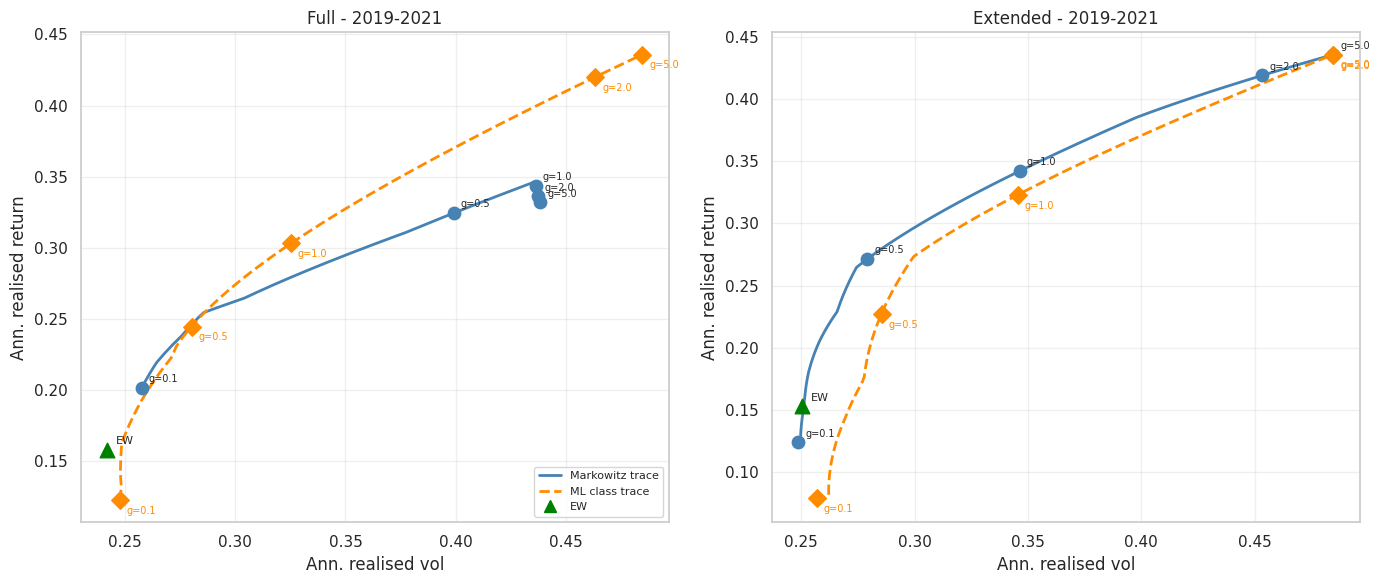

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

panels = [
    (axes[0], "Full",     mk_v_full, mk_r_full, cls_v_full, cls_r_full,
     w_mk_full, w_cls_full, w_ew_full, test_full),
    (axes[1], "Extended", mk_v_ext,  mk_r_ext,  cls_v_ext,  cls_r_ext,
     w_mk_ext,  w_cls_ext,  w_ew_ext,  test_ext),
]

for ax, lbl, mv, mr, cv, cr, wm, wc, we, tr in panels:
    ax.plot(mv, mr, color="steelblue",  lw=2)
    ax.plot(cv, cr, color="darkorange", lw=2, ls="--")
    for g in GAMMAS:
        v, r = realized_point(wm[g], tr)
        ax.scatter(v, r, color="steelblue", s=80, zorder=5)
        ax.annotate(f"g={g}", (v, r), xytext=(5, 4), textcoords="offset points", fontsize=7)
        if g in wc:
            v2, r2 = realized_point(wc[g], tr)
            ax.scatter(v2, r2, color="darkorange", s=80, marker="D", zorder=5)
            ax.annotate(f"g={g}", (v2, r2), xytext=(5, -10), textcoords="offset points",
                        fontsize=7, color="darkorange")
    v_ew, r_ew = realized_point(we, tr)
    ax.scatter(v_ew, r_ew, color="green", s=110, marker="^", zorder=5)
    ax.annotate("EW", (v_ew, r_ew), xytext=(6, 4), textcoords="offset points", fontsize=8)
    ax.set(xlabel="Ann. realised vol", ylabel="Ann. realised return",
           title=f"{lbl} - 2019-2021")
    ax.grid(True, alpha=0.3)

handles = [
    Line2D([0], [0], color="steelblue",  lw=2,            label="Markowitz trace"),
    Line2D([0], [0], color="darkorange", lw=2, ls="--",   label="ML class trace"),
    Line2D([0], [0], color="green",      lw=0, marker="^", markersize=9, label="EW"),
]
axes[0].legend(handles=handles, fontsize=8, loc="lower right")
plt.tight_layout()
plt.show()

Overlap-band comparison: at the lowest common volatility, which trace sits higher?

In [52]:
def _trace_read(lbl, mk_v, mk_r, cls_v, cls_r):
    overlap_lo = max(mk_v.min(), cls_v.min())
    overlap_hi = overlap_lo + 0.02
    mk_mask    = (mk_v  >= overlap_lo) & (mk_v  <= overlap_hi)
    cls_mask   = (cls_v >= overlap_lo) & (cls_v <= overlap_hi)
    if mk_mask.any() and cls_mask.any():
        mk_lo  = mk_r[mk_mask].mean()
        cls_lo = cls_r[cls_mask].mean()
        print(f"{lbl}: overlap band [{overlap_lo:.2%}, {overlap_hi:.2%}] - "
              f"ML {cls_lo:.2%} vs Mk {mk_lo:.2%}, edge {cls_lo - mk_lo:+.2%}.")
    else:
        print(f"{lbl}: traces don't overlap in vol range "
              f"(Mk min {mk_v.min():.2%}, ML min {cls_v.min():.2%}).")


_trace_read("Full",     mk_v_full, mk_r_full, cls_v_full, cls_r_full)
_trace_read("Extended", mk_v_ext,  mk_r_ext,  cls_v_ext,  cls_r_ext)

Full: overlap band [25.75%, 27.75%] - ML 21.87% vs Mk 22.28%, edge -0.41%.
Extended: overlap band [25.68%, 27.68%] - ML 12.09% vs Mk 23.43%, edge -11.34%.


## Interpretation

- **Feature selection differs by universe.** Stage A leaves all three feature groups in Full but drops monthly lags from Extended (the longer history makes them noisier). Stage B then picks the best RM-window subset for each. Final feature count: Full 20 features (all three RM windows), Extended 6 features (`rm_252` only plus surviving daily lags). The Extended fold mean Sharpe (1.82) exceeds the Full mean Sharpe (1.24) with less than a third of the features.
- **Rolling-mean features dominate.** Full top-3 importance is all RM (`rm_126` 9.0%, `rm_252` 8.3%, `rm_63` 7.9%); Extended top-3 mixes `rm_252` (20.7%) with short-term daily lags (`ret_lag_1` 16.3%, `ret_lag_5` 16.2%). Monthly lags are weak predictors on both — confirmed by Stage A explicitly dropping them on Extended.
- **Classifier separates cleanly on Full, marginally on Extended.** Full buy−sell mean-return spread is +1.84% (buy acc 53.4%), so $P > 0.5$ does meaningfully separate winners from losers. Extended spread is **−0.04%** (buy acc 51.1%) — essentially random for the buy/sell split, even though Spearman rank IC stays positive (mean 0.013, IR 0.06). The classifier ranks on Extended but doesn't usefully threshold.
- **ML screen wins at higher $\gamma$ on Full; loses on Extended.** At $\gamma \ge 0.5$ on Full, ML-class + Markowitz beats plain Markowitz on realised Sharpe at all 4 grid points (Δ ≈ +0.08 to +0.17). On Extended, plain Markowitz wins at γ ∈ {0.1, 0.5, 1.0, 2.0} and ties at γ = 5.0 (both Sharpe 0.965, Δ = 0.000) — consistent with bullet 3's null buy/sell separation on Extended.
- **Trace overlap.** In the common volatility band (~25–27%, the high-vol end where ML's trace reaches and Markowitz's begins), plain Markowitz edges ML on both universes — by 0.41% on Full and 11.34% on Extended. The discrete γ comparison and the continuous trace tell different stories on Full because the trace only overlaps in the narrow upper-vol band, whereas the discrete sweep includes mid-γ values where ML wins.

## Limitations

- **Single train/test split.** No out-of-sample retraining or rolling refit. The classifier sees data only up to 2018-12-31; test runs 2019-2021 once. Walk-forward over multiple test windows would give a more robust estimate of OOS performance.
- **EWMA $\mu$ on the test side.** $\hat\mu$ is estimated on train data and then used to price portfolio decisions over a 2.5-year test window with no re-estimation. In practice $\hat\mu$ regime-shifts over that span; that error sits at the heart of the Markowitz fragility.
- **Frictionless backtest.** No transaction costs, turnover penalties, or market-impact model. Sharpe / CAGR / drawdown gross of friction.
- **No shorting or leverage.** All formulations enforce $w \ge 0$, $\mathbf 1^\top w = 1$.
- **Classifier threshold is a free hyperparameter.** $P > 0.51$ is fixed across the notebook. A higher threshold tightens the screen but also reduces the number of admissible stocks; a sweep over thresholds would expose this trade-off.
- **Seed-dependent.** XGBoost initialisation, sample-weight shuffling, and SCS solver tolerances all carry seeds. Rerunning with a different seed shifts the exact numbers slightly; the qualitative conclusions are stable.